# Comparing the numerical and analytical solutions

Testing if the boundary conditions prescribed to the numerical solver result in the same solution as the analytical one that we started out with,
$$
    \tilde{h}(\tilde{x},\tilde{y}) = \frac{i\gamma}{4}H^{(1)}_{0}\left(\frac{\omega\gamma}{c}(\gamma^2\tilde{x}^2+\tilde{y}^2)^{\frac{1}{2}}\right)\mathrm{e}^{i\omega\gamma^2\frac{U}{c^2}\tilde{x}},
$$
When non-dimensionalised, we get:
$$
    \tilde{h}(\tilde{x},\tilde{y}) = \frac{i\gamma}{4}H^{(1)}_{0}\left(\gamma(\gamma^2\tilde{x}^2+\tilde{y}^2)^{\frac{1}{2}}\right)\mathrm{e}^{iv\gamma^2\tilde{x}},
$$

In [1]:
using JuMP
import Ipopt
using Plots
using LinearAlgebra
using SpecialFunctions
using LaTeXStrings
include(relpath("functions/integral_functions.jl","shape-in-wdp"))
include(relpath("functions/finite_functions.jl","shape-in-wdp"))

second_back_y_ho6 (generic function with 1 method)

Set the following to true if you want to save the gifs

In [2]:
"""
    Calculates the Lorentz factor γ for a given velocity
"""
function gam(vel)
    return (1-vel^2)^(-1/2)
end

# gam(0.5)

gam

## Analytical 

In [ ]:
velocity = 0.5 # dimensionless velocity v
lorentz = gam(velocity)
lam = lorentz
l_outer = 15pi/2
divs = 300
n = divs +1
dx = l_outer/divs
lhs = -l_outer/2

hank_vel_test = zeros(n,n)
hank_vel_test_imag = zeros(n,n)

axes_vals = zeros(n)

for i in 1:n
    for j in 1:n
        y = lhs + (i-1)*dx
        x = lhs + (j-1)*dx
        hank_vel_test[i,j] = (gam(velocity)*real((1im/4)*hankelh1(0,lam*sqrt(y^2
                            +(lorentz^2)*(x^2)))*(cos(x*(lorentz^2)*velocity)
                            +1im*sin(x*lorentz^2*velocity))))
        hank_vel_test_imag[i,j] = (gam(velocity)*imag((1im/4)*hankelh1(0,lam*sqrt(y^2
                                +(lorentz^2)*(x^2)))*(cos(x*(lorentz^2)*velocity)
                                +1im*sin(x*lorentz^2*velocity))))
        axes_vals[i] = y
    end
end


0

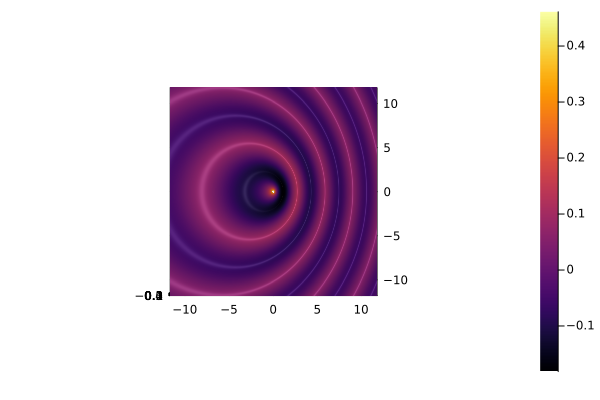

In [4]:
surface(axes_vals,axes_vals,hank_vel_test,camera=(0,90))

## Numerical 

In [5]:
#= 
    Functions that we will need 
=# 

"""
    Defines the 2d regularised Dirac delta distribution.
"""
function delta_func(a,y,x)
    return (1/(2*pi*(a^2)))*exp(-(x^2+y^2)/(2*a^2))
end

"""
    cos(θ) effective angle
"""
function cos_theta(y,x,gamma)
    return (x*gamma)/(sqrt(x^2*gamma^2 + y^2))
end

"""
    sin(θ) effective angle
"""
function sin_theta(y,x,gamma)
    return y/(sqrt(x^2*gamma^2 + y^2))
end


sin_theta

Solver (built using JuMP to then become an optimisation function)

In [18]:
include("subcrit_solver.jl")

new_bc

In [ ]:
a = vel_opti(velocity,3pi/2,15pi/2,300,true);

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:  1265998
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:   181202
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:   181202
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0000000e+00 2.58e+01 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [20]:
tick_array = -15pi/4:dx:15pi/4

-11.780972450961723:0.07853981633974483:11.780972450961723

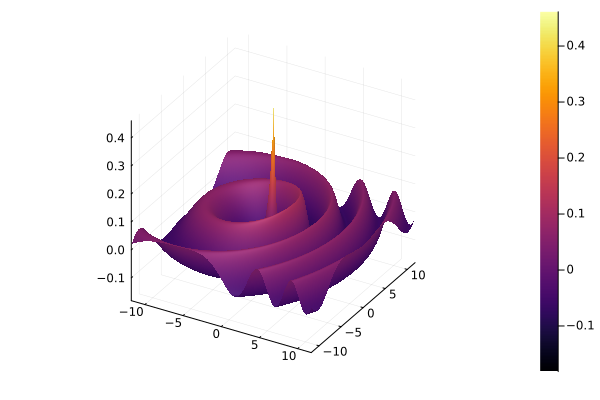

In [21]:
surface(tick_array,tick_array,hank_vel_test)

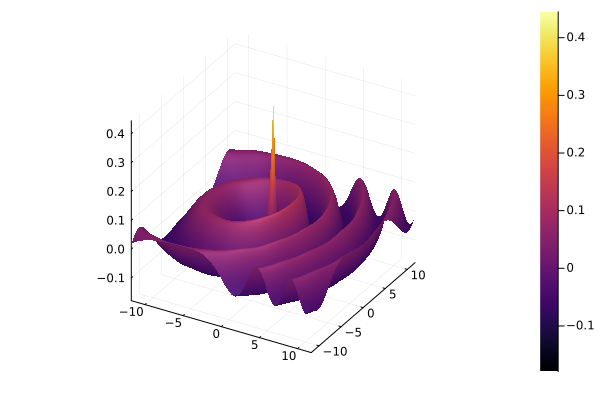

In [22]:
surface(tick_array,tick_array,a[3])

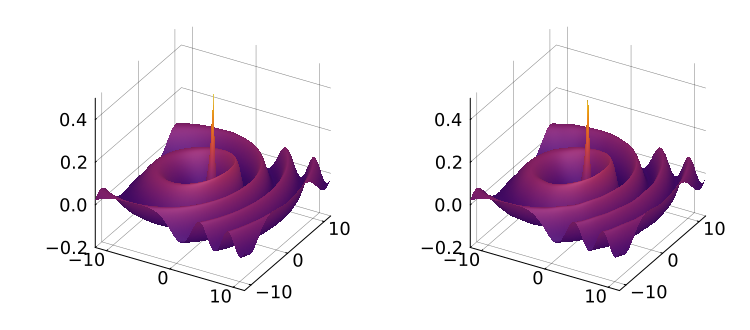

In [24]:
plt = surface(surface(tick_array,tick_array,hank_vel_test),#,title="Hankel real v=$velocity"),
        surface(tick_array,tick_array,a[3])#, title="Numerical real v=$velocity")
        ,colorbar=false,
        xticks=[-10,0,10],yticks=[-10,0,10],
        zlims=(-0.2,0.5),size=(750,330),
        margin=0Plots.cm,
        labelfontsize=15,tickfontsize=12,gridalpha=0.5)
# savefig(plt, "plots\\analytical_numerical_compare_0_9.pdf")

In [50]:
num_h_real = a[3];
num_h_imag = a[4];

## Quantify the difference between the two

First I will calculate the residual for each point as a matrix, then plot it and after get RSS or something

In [51]:
res_real = hank_vel_test - num_h_real;
res_imag = hank_vel_test_imag - num_h_imag;

abs_res_real = zeros(n,n)
abs_res_imag = zeros(n,n)

for i in 1:n
    for j in 1:n
        abs_res_real[i,j] = abs(res_real[i,j])
        abs_res_imag[i,j] = abs(res_imag[i,j])
    end
end


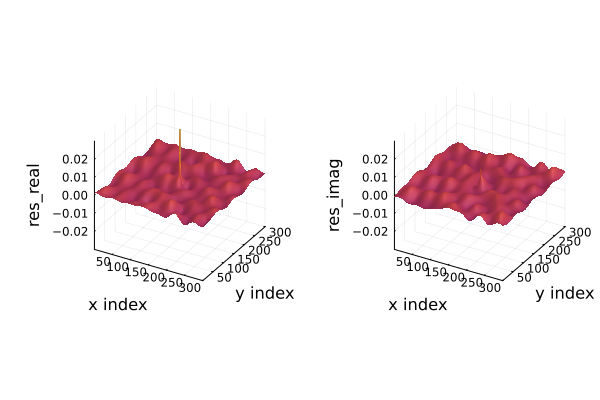

In [52]:
plt = Plots.plot(surface(res_real, zlabel="res_real"),surface(res_imag, zlabel="res_imag")
        ,colorbar=false,zlims=[-0.03,0.03],xlabel="x index", ylabel="y index")


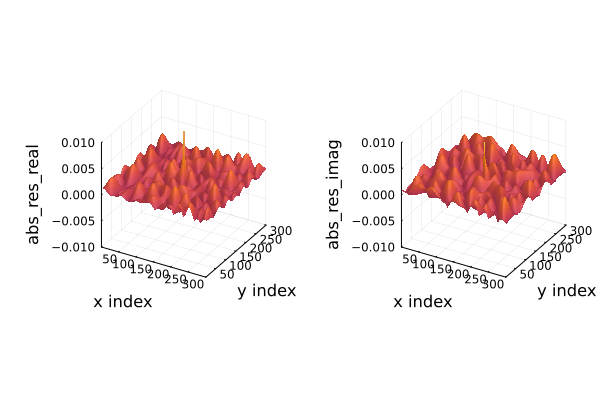

In [53]:
plt = Plots.plot(surface(abs_res_real, zlabel="abs_res_real"),surface(abs_res_imag, zlabel="abs_res_imag")
        ,colorbar=false,zlims=[-0.01,0.01],xlabel="x index",ylabel="y index")

In [54]:
# normalising with the maximum height 
nrm_res_real = zeros(n,n);
nrm_res_imag = zeros(n,n);
for i in 1:n
    for j in 1:n
        nrm_res_real[i,j] = res_real[i,j]/0.3
        nrm_res_imag[i,j] = res_imag[i,j]/0.3
    end
end

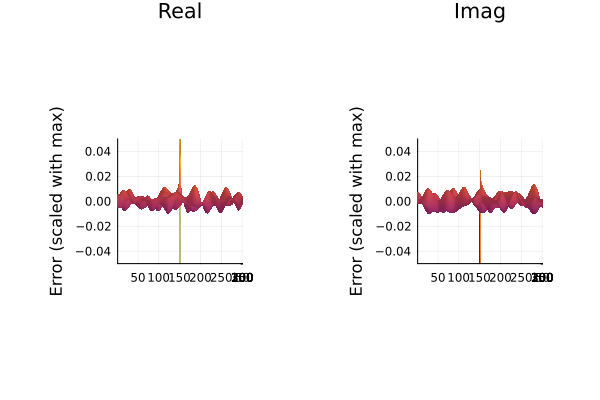

In [55]:
Plots.plot(surface(nrm_res_real,title="Real",zlabel="Error (scaled with max)"),
    surface(nrm_res_imag,zlabel="Error (scaled with max)",title="Imag"),
    colorbar=false,zlims = [-0.05,0.05],camera=(0,0))

Could also think about comparing the maximal extend of each wave.

In [56]:
max_num_real = norm(num_h_real,Inf)
max_num_imag = norm(num_h_imag,Inf)
# set the NaN to zero to make our check better
hank_real = hank_vel_test
hank_real[151,151] = 0
hank_imag = hank_vel_test_imag
hank_imag[151,151] = 0
max_ana_real = norm(hank_real,Inf)
max_ana_imag = norm(hank_imag,Inf)

print("L_infinty norms of the matrices\n",
      "hank_real = ", max_ana_real, "\n",
      "hank_imag = ", max_ana_imag, "\n",
      "num_real = ", max_num_real, "\n",
      "num_imag = ", max_num_imag)

L_infinty norms of the matrices
hank_real = 0.4610973632309224
hank_imag = 0.3156496337457587
num_real = 0.4449312271996522
num_imag = 0.3093333027211791

In [58]:
res_real = hank_vel_test - num_h_real;
res_imag = hank_vel_test_imag - num_h_imag;

abs_res_real = zeros(n,n)
abs_res_imag = zeros(n,n)

for i in 1:n
    for j in 1:n
        abs_res_real[i,j] = abs(res_real[i,j])
        abs_res_imag[i,j] = abs(res_imag[i,j])
    end
end


In [59]:
for i in 148:154
    for j in 148:154
        abs_res_real[i,j] = 0
        abs_res_imag[i,j] = 0
    end
end

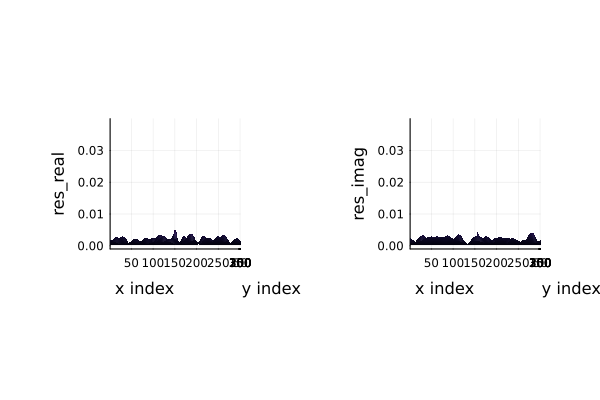

In [60]:
plt = Plots.plot(surface(abs_res_real, zlabel="res_real"),surface(abs_res_imag, 
                zlabel="res_imag")
        ,colorbar=false,xlabel="x index", ylabel="y index",zlims=(-0.001,0.04),
        camera=(0,0))
# savefig(plt,"plots\\residual_abs_0_5_mid_remove.pdf")

### Take the largest absolute difference

Will just isolate all the points

In [61]:
max_diff_real = norm(abs_res_real,Inf)
max_diff_imag = norm(abs_res_imag,Inf)
print("max diff real = ", max_diff_real,"\n",
        "max diff imag = ", max_diff_imag)

max diff real = 0.004961526778024611
max diff imag = 0.004418601597749872

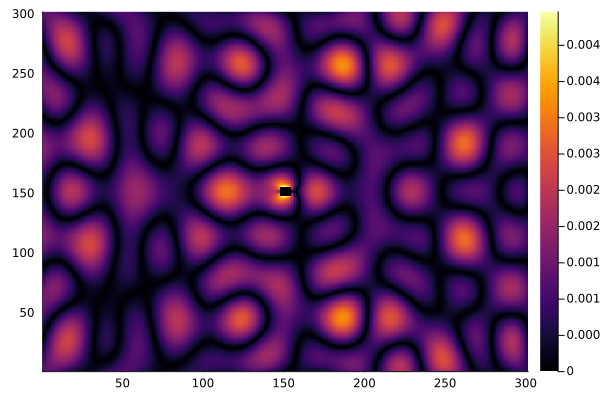

In [62]:
heatmap(abs_res_real)

#### Writing a loop to find absolute value and scale it with maximal value

In [63]:
# making hankel function code into a function to simply call
function ana_sol(velocity)
    lorentz = gam(velocity)
    lam = lorentz
    l_outer = 15pi/2
    divs = 300
    n = divs +1
    dx = l_outer/divs
    lhs = -l_outer/2

    hank_vel_test = zeros(n,n)
    hank_vel_test_imag = zeros(n,n)

    for i in 1:n
        for j in 1:n
            y = lhs + (i-1)*dx
            x = lhs + (j-1)*dx
            hank_vel_test[i,j] = (gam(velocity)*real((1im/4)*hankelh1(0,lam*sqrt(y^2
                                +(lorentz^2)*(x^2)))*(cos(x*(lorentz^2)*velocity)
                                +1im*sin(x*lorentz^2*velocity))))
            hank_vel_test_imag[i,j] = (gam(velocity)*imag((1im/4)*hankelh1(0,lam*sqrt(y^2
                                    +(lorentz^2)*(x^2)))*(cos(x*(lorentz^2)*velocity)
                                    +1im*sin(x*lorentz^2*velocity))))
        end
    end
    return hank_vel_test, hank_vel_test_imag
end

ana_sol (generic function with 1 method)

In [64]:
index_num = 1
diff_r = zeros(length(0:0.01:0.98))
diff_i = zeros(length(0:0.01:0.98))
max_r = zeros(length(0:0.01:0.98))
max_i = zeros(length(0:0.01:0.98))
vel = zeros(length(0:0.01:0.98))
n = 301

for v in 0:0.01:0.98
    # calculate matrices 
    num = vel_opti(v);
    ana = ana_sol(v)
    # get the difference btween the two
    res_real = ana[1] - num[3];
    res_imag = ana[2] - num[4];
    # get the absolute difference
    abs_res_real = zeros(n,n)
    abs_res_imag = zeros(n,n)

    for i in 1:n
        for j in 1:n
            abs_res_real[i,j] = abs(res_real[i,j])
            abs_res_imag[i,j] = abs(res_imag[i,j])
        end
    end

    # get rid of singularity issues
    for i in 148:154
        for j in 148:154
            abs_res_real[i,j] = 0
            abs_res_imag[i,j] = 0
            ana[1][i,j] = 0
            ana[2][i,j] = 0
        end
    end
    max_diff_real = norm(abs_res_real,Inf)
    max_diff_imag = norm(abs_res_imag,Inf)

    diff_r[index_num] = max_diff_real
    diff_i[index_num] = max_diff_imag

    # find maximal values
    max_a_r = norm(ana[1],Inf)
    max_a_i = norm(ana[2],Inf)

    max_r[index_num] = max_a_r
    max_i[index_num] = max_a_i

    vel[index_num] = v
    print(index_num, "\t")
    index_num += 1

end


1	2	3	4	5	6	7	8	9	10	11	12	13	14	15	16	17	18	19	20	21	22	23	24	25	26	27	28	29	30	31	32	33	34	35	36	37	38	39	40	41	42	43	44	45	46	47	48	49	50	51	52	53	54	55	56	57	58	59	60	61	62	63	64	65	66	67	68	69	70	71	72	73	74	75	76	77	78	79	80	81	82	83	84	85	86	87	88	89	90	91	92	93	94	95	96	97	98	99	

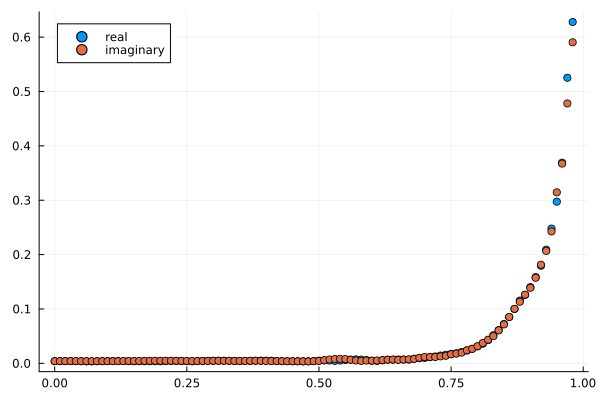

In [69]:
scatter(vel,diff_r,label="real")
scatter!(vel,diff_i,label="imaginary")

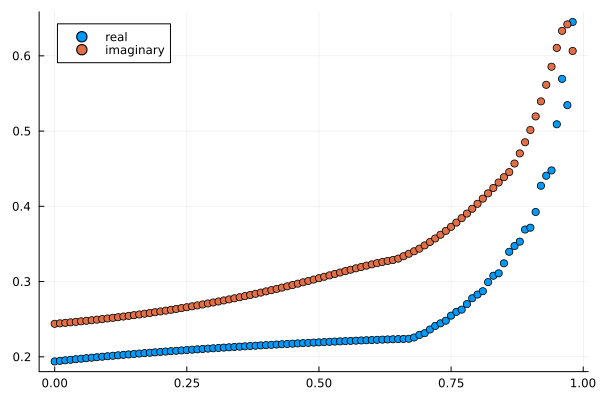

In [66]:
scatter(vel,max_r,label="real")
scatter!(vel,max_i,label="imaginary")

In [67]:
# scaling 
scaled_r = zeros(length(0:0.01:0.98))
scaled_i = zeros(length(0:0.01:0.98))
for i in 1:length(0:0.01:0.98)
    scaled_r[i] = diff_r[i]/max_r[i]
    scaled_i[i] = diff_i[i]/max_i[i]
end

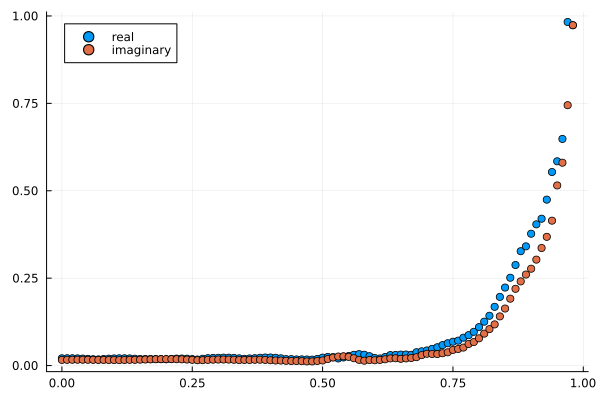

In [68]:
scatter(vel,scaled_r,label="real")
scatter!(vel,scaled_i,label="imaginary")